<a href="https://colab.research.google.com/github/aydanali/ECON3916-Stats-and-ML/blob/main/Assignment4/Econ_3916_Assignment_4_Predictive_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.1 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import missingno as msno
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
vitals_url = 'https://raw.githubusercontent.com/aydanali/ECON3916-Stats-and-ML/refs/heads/main/Data/OmniCare_Clinical_Vitals.csv'
vitals_df = pd.read_csv(vitals_url)
vitals_df

,Patient_ID,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP
0,1000,177.5,66.3,21.06,110.0,75.0
1,1001,167.9,57.5,20.39,115.0,79.0
2,1002,179.7,57.4,17.77,111.0,77.0
3,1003,192.8,80.9,21.76,122.0,88.0
4,1004,166.5,65.7,23.70,138.0,89.0
...,...,...,...,...,...,...
4995,5995,169.3,72.7,25.39,106.0,76.0
4996,5996,180.7,56.6,17.34,139.0,100.0
4997,5997,216.7,99.4,21.16,140.0,96.0
4998,5998,182.1,77.9,23.48,107.0,83.0


In [8]:
telem_url = 'https://raw.githubusercontent.com/aydanali/ECON3916-Stats-and-ML/refs/heads/main/Data/OmniCare_Telemetry_Data.csv'
telem_df = pd.read_csv(telem_url)
telem_df

,Patient_ID,High_Deductible_Insurance_Plan,Inpatient_Admission_Rate,Continuous_Heart_Rate,Primary_Diagnosis_Code,Clinic_Capacity_Percentage,Time_of_Day_Index,Procedure_Cost_USD
0,1000,1,0.341,76.9,J86.381,0.63,19.4,1635.84
1,1001,0,0.213,79.6,M29.789,0.71,19.3,1355.77
2,1002,0,0.166,92.3,E49.618,0.76,16.8,1189.19
3,1003,1,0.143,79.3,E66.244,0.52,11.5,1250.93
4,1004,0,0.219,75.9,J45.553,0.65,20.2,1986.34
...,...,...,...,...,...,...,...,...
4995,5995,1,0.140,52.2,M96.598,0.58,3.7,1150.29
4996,5996,0,0.152,76.0,M63.490,0.68,17.6,1739.46
4997,5997,0,0.363,91.0,C64.505,0.77,2.3,1713.14
4998,5998,0,0.118,53.5,A23.926,0.55,9.2,1589.11


# Phase 1

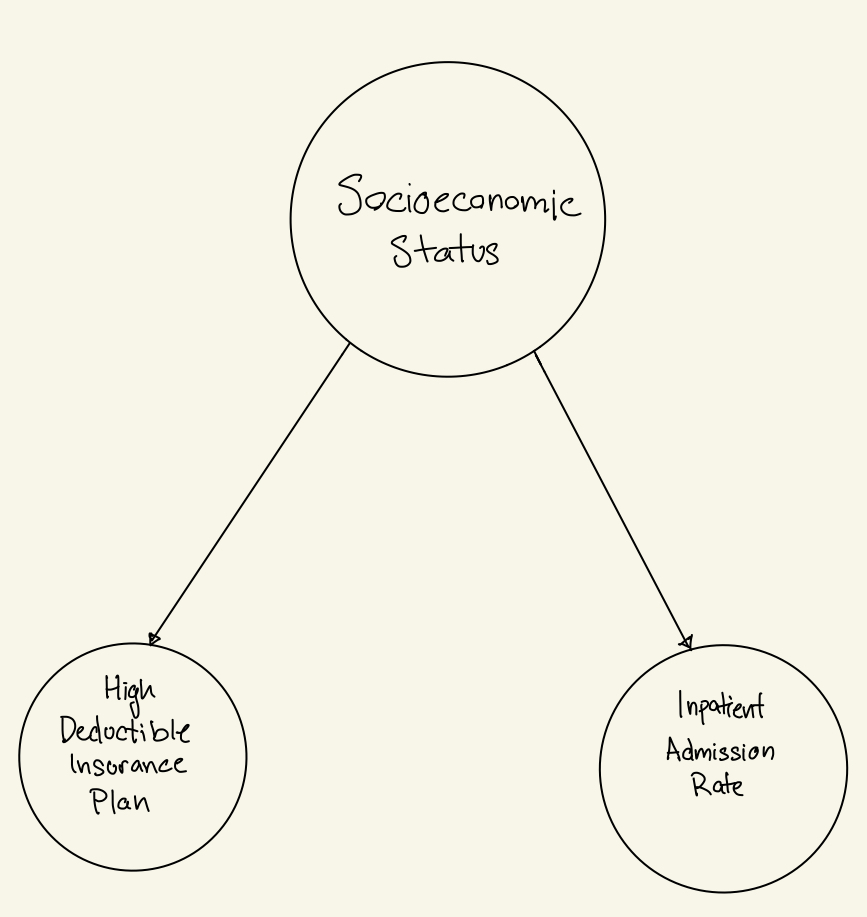

Task: Identify the omitted confounder. Draw the causal Directed Acyclic Graph (DAG) representing a "Fork" structure that explains this spurious correlation (e.g., consider unobserved patient baseline wealth or systemic poverty). Explain theoretically why regressing Admission on Insurance Type without controlling for this confounder yields a biased, mathematically contaminated predictive weight.

The biggest omitted confounder would be a patient's socioeconomic status. Patients with lower socioeconomic status may visit the doctor less frequently, receieve less preventative treatment, and are less likely to be able to afford high quality healthcare (or be provided one by an employer). Along with this, patients will lower socioeconomic status are more likely to enroll in high-deductable plans since it is has cheaper premiums.

Socioeconomic status is highly correlated with insurance type (`High_Deductible_Insurance_Plan`) and is a large driver of a patient's admission rate (`Inpatient_Admission_Rate`). Without controling for socioeconomic status, you would assign the effect of socicoeconomic status has onto insurance type because it is a correlated variable.

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

x_df = vitals_df[['Weight_kg', 'Height_cm', 'BMI', 'Systolic_BP', 'Diastolic_BP']]
x = sm.add_constant(x_df)

vif = pd.DataFrame()
vif['features'] = x.columns

vif_values = []
for i in range(x.shape[1]):
  vif_values.append(variance_inflation_factor(x.values, i))
vif['VIF'] = vif_values

vif

,features,VIF
0,const,3369.565806
1,Weight_kg,57.428058
2,Height_cm,28.419446
3,BMI,16.981232
4,Systolic_BP,4.219406
5,Diastolic_BP,4.219820


The features `Weight_kg`, `Height_cm`, and `BMI` are highly correlated and all have VIFs over the critical point of 10. To relieve the multicollinearity, I will drop `Weight_kg` and `Height_cm`. `BMI` should cover both and give the effect we are looking for.

In [25]:
r_df = vitals_df[['BMI', 'Systolic_BP', 'Diastolic_BP']]
r = sm.add_constant(r_df)

vif_2 = pd.DataFrame()
vif_2['features'] = r.columns

vif_values_2 = []
for i in range(r.shape[1]):
  vif_values_2.append(variance_inflation_factor(r.values, i))
vif_2['VIF'] = vif_values_2
vif_2 = vif_2[vif_2['features'] != 'const']

vif_2

,features,VIF
1,BMI,1.000178
2,Systolic_BP,4.219207
3,Diastolic_BP,4.219571


In [37]:
vitals_df_cleaned = vitals_df.drop(['Weight_kg', 'Height_cm'], axis=1)
vitals_df_cleaned

,Patient_ID,BMI,Systolic_BP,Diastolic_BP
0,1000,21.06,110.0,75.0
1,1001,20.39,115.0,79.0
2,1002,17.77,111.0,77.0
3,1003,21.76,122.0,88.0
4,1004,23.70,138.0,89.0
...,...,...,...,...
4995,5995,25.39,106.0,76.0
4996,5996,17.34,139.0,100.0
4997,5997,21.16,140.0,96.0
4998,5998,23.48,107.0,83.0


# Phase 2

<Axes: >

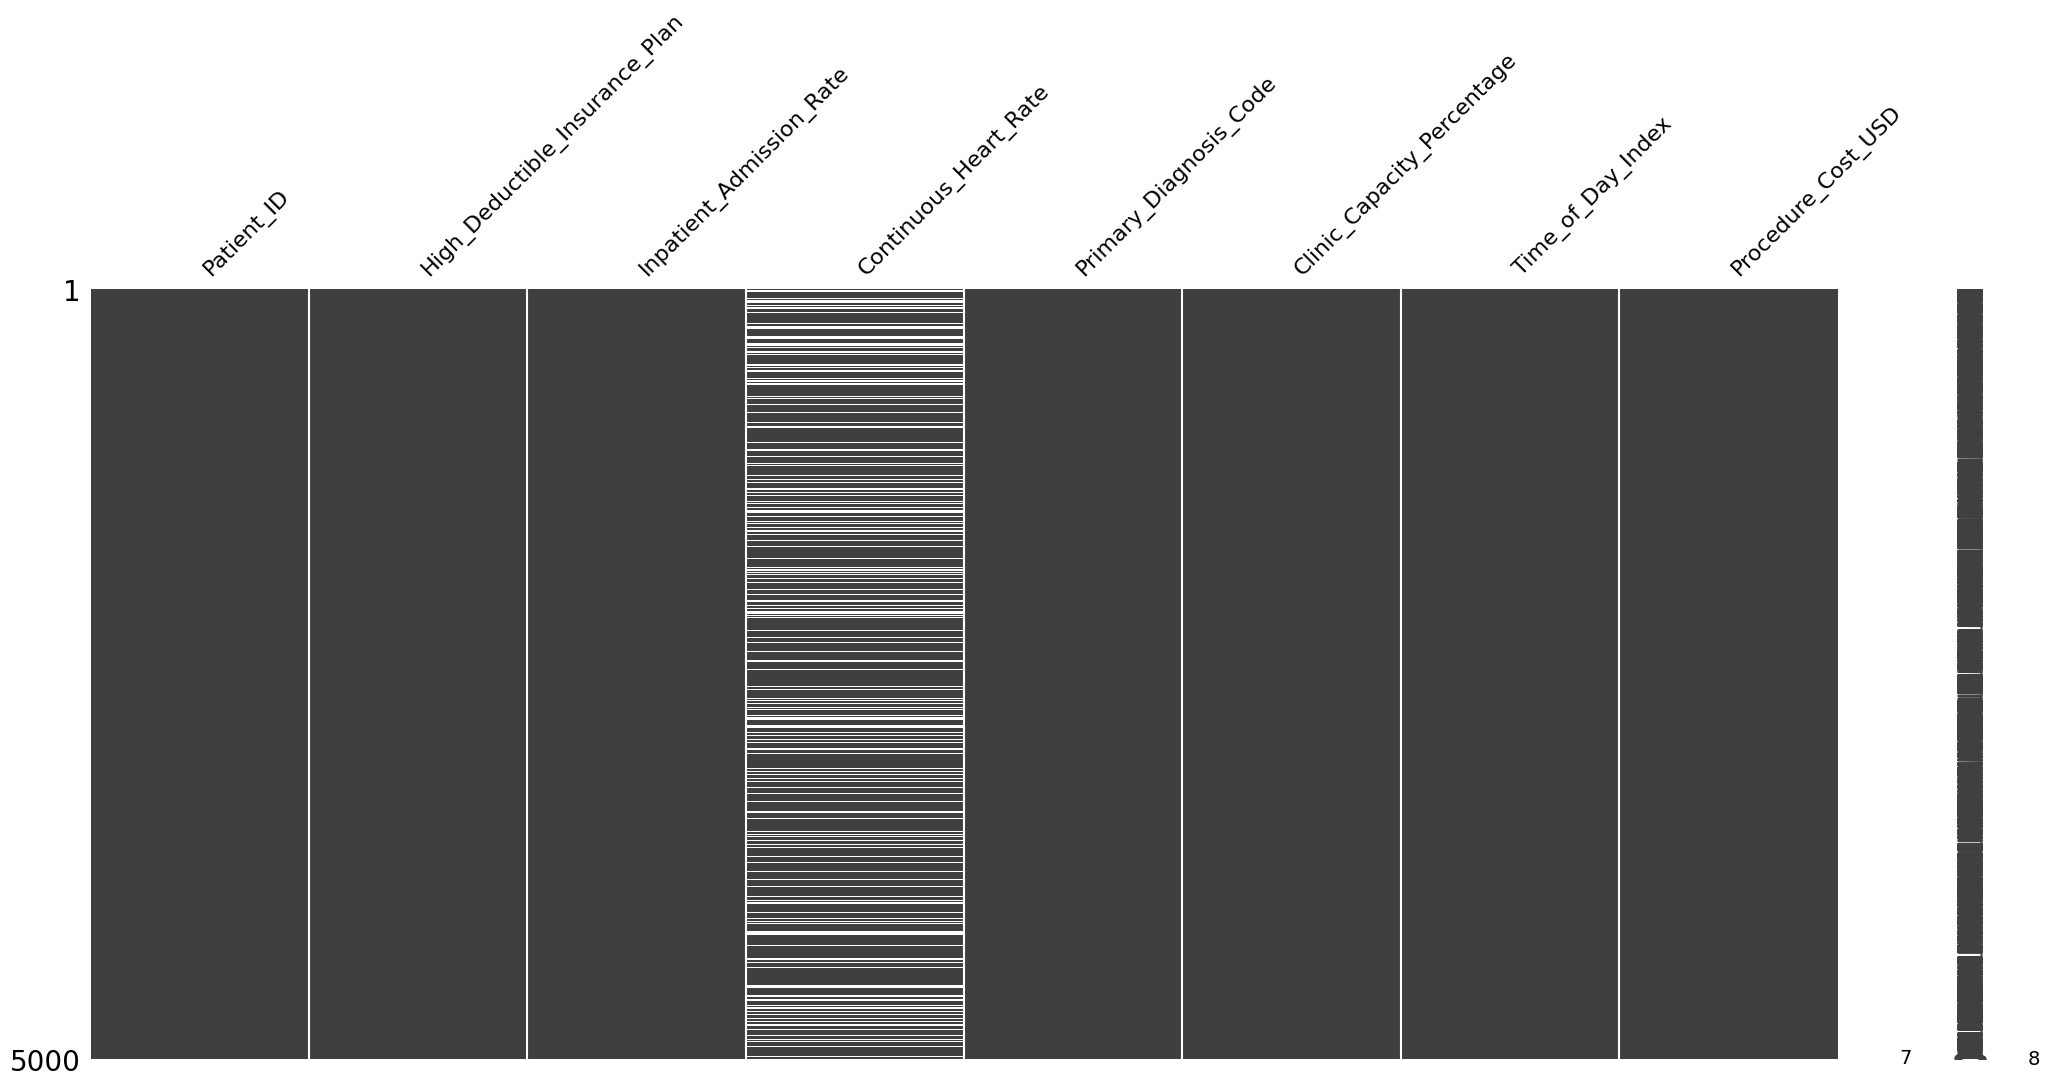

In [26]:
msno.matrix(telem_df)

The missing data is MNAR (missing not at random). Donald Rubin's taxonomy theory suggests that low-income patients systematically refuse to transmit telemetry due to the data-plan costs associated with continuous streaming. The continuous monitoring of heart rate will cost data continuously. Data-plans, espically lower cost plans, are less expensive and are more likely to be used by lower-income patients. With that, this data is not missing at random in any degree because the missing data comes from those who are not continiously transmitting their heart rate data.

Creating a dummy variable for all the diagnosis codes would give the each row 850 columns with all but one having a 0 (the remain columning having a 1). This not only doesn't give any helpful information because you would need to parse through 850 columns to figure out a diagnosis code, but it also creates a matrix of columns that, along with inclusion of a constant intercept term, hurts the OLS regression because of the multicollinearity. The 850 columns all tell the same story that the single column did before. When you are able to determine the value of column(s) with others, then there will be overfitting towards those correlated variables.

In [32]:
target = ce.TargetEncoder('Primary_Diagnosis_Code')

telem_df['Target_Encoded_Diagnosis'] = target.fit_transform(telem_df['Primary_Diagnosis_Code'], telem_df['Procedure_Cost_USD'])

telem_df[['Procedure_Cost_USD', 'Primary_Diagnosis_Code', 'Target_Encoded_Diagnosis']].head()

,Procedure_Cost_USD,Primary_Diagnosis_Code,Target_Encoded_Diagnosis
0,1635.84,J86.381,1707.697108
1,1355.77,M29.789,1792.303198
2,1189.19,E49.618,1730.334968
3,1250.93,E66.244,1725.060944
4,1986.34,J45.553,1801.821085


# Phase 3

In [40]:
df = pd.merge(vitals_df_cleaned, telem_df, on='Patient_ID')
df

,Patient_ID,BMI,Systolic_BP,Diastolic_BP,High_Deductible_Insurance_Plan,Inpatient_Admission_Rate,Continuous_Heart_Rate,Primary_Diagnosis_Code,Clinic_Capacity_Percentage,Time_of_Day_Index,Procedure_Cost_USD,Primary_Diagnosis_Code_Target_Encoder,Target_Encoded_Diagnosis
0,1000,21.06,110.0,75.0,1,0.341,76.9,J86.381,0.63,19.4,1635.84,1707.697108,1707.697108
1,1001,20.39,115.0,79.0,0,0.213,79.6,M29.789,0.71,19.3,1355.77,1792.303198,1792.303198
2,1002,17.77,111.0,77.0,0,0.166,92.3,E49.618,0.76,16.8,1189.19,1730.334968,1730.334968
3,1003,21.76,122.0,88.0,1,0.143,79.3,E66.244,0.52,11.5,1250.93,1725.060944,1725.060944
4,1004,23.70,138.0,89.0,0,0.219,75.9,J45.553,0.65,20.2,1986.34,1801.821085,1801.821085
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,5995,25.39,106.0,76.0,1,0.140,52.2,M96.598,0.58,3.7,1150.29,1714.992854,1714.992854
4996,5996,17.34,139.0,100.0,0,0.152,76.0,M63.490,0.68,17.6,1739.46,1739.638804,1739.638804
4997,5997,21.16,140.0,96.0,0,0.363,91.0,C64.505,0.77,2.3,1713.14,1715.834832,1715.834832
4998,5998,23.48,107.0,83.0,0,0.118,53.5,A23.926,0.55,9.2,1589.11,1759.303097,1759.303097


In [42]:
formula = 'Procedure_Cost_USD  ~ Target_Encoded_Diagnosis + Clinic_Capacity_Percentage + Time_of_Day_Index + BMI	+ Systolic_BP +	Diastolic_BP'
baseline_model = smf.ols(formula, data=df).fit()
print(baseline_model.summary())

                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     267.0
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          3.60e-297
Time:                        04:43:41   Log-Likelihood:                -36162.
No. Observations:                5000   AIC:                         7.234e+04
Df Residuals:                    4993   BIC:                         7.238e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [51]:
from statsmodels.tools.eval_measures import rmse

predictors = baseline_model.predict(df)
model_rmse = rmse(df['Procedure_Cost_USD'], predictors)

print('Model RMSE in USD: $', round(model_rmse, 2))

Model RMSE in USD: $ 334.79


The RMSE represents the distance between predicted values and their actual observed values. In this case, the estimated difference between the predicted values and the actual values was $334.79. Implimenting models like this into dynamic pricing of various treatments can create serious concerns. It would cause the mis-pricing of treatments for patients and insurers, creating poor resource allocation and incorrect funding. If the model incorrectly predicts the cost treatment to be over what insurance would cover, a patient may not recieve the care needed. On the other hand, if the model underestimates the price then all the resources may not be properly fianced (e.g. salaries, machine costs, etc.). The model is also not able to provide transparency in its pricing deceicison. Although we can see the regressors, we do not have the exact information nor can we ask the model to justify its pricing choices. There are many laws that protect the rights of patients, and having autonomous dynamic pricing would violate many patient rights.

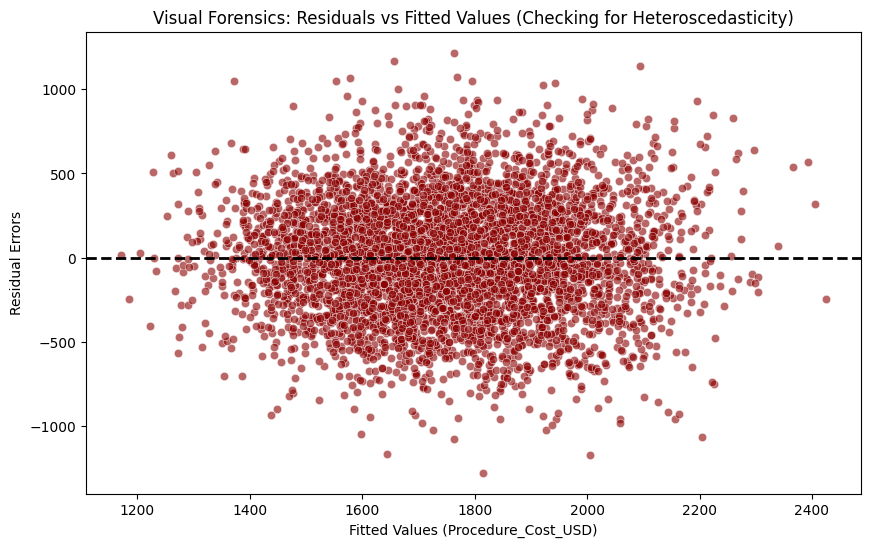

In [53]:
fitted_vals = baseline_model.fittedvalues
residuals = baseline_model.resid

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_vals, y=residuals, alpha=0.6, color='darkred')
plt.axhline(0, color='black', linestyle='--', linewidth=2)
plt.title('Visual Forensics: Residuals vs Fitted Values (Checking for Heteroscedasticity)')
plt.xlabel('Fitted Values (Procedure_Cost_USD)')
plt.ylabel('Residual Errors')
plt.show()

The scatter plot shows little, but some spreading as the predicted procedure cost increases. There are less instances, but they are more spread away from the x axis, espically in the positive direction. This flaw shows that the alogrithm is less reliabile at peak surge-pricing tiers. In many cases, the model was off by for 500. With some more instances having a positive residual error, patients, espically those with who require more expensive treatments or treatments are more expensive times, will likely receieve incorrect estimates that will cost them and their insurers more than necessary.

# Phase 4

[Prep] Act as a modern Tech Economist studying machine learning's effect on healthcare pricing.



[Request] I just completed a study where I used python to create an OLS regression for the dynamic pricing of certain medical procedures in a hospital using statsmodel. Now I want to expand this by running a White's Lagrange Multiplier Test for Heteroscedasticity on my exact OLS model output, utilizing the statsmodels.stats.diagnostic.het_white function. Please write the python code to do this and give the p-value of the test.



[Iterate] The code should use statsmodels.stats.diagnostic's het_white library and any other necessary tools.



[Mechanism Check] Add inline comments explaining exactly how the test is running and the broad purpose of each section of the code in order for a user to follow the mechanisms.



[Evaluate] Provide a brief explanation how to interpret the p-values and the importance of the White LM test.

In [54]:
from statsmodels.stats.diagnostic import het_white
import statsmodels.api as sm

# ── STEP 1: Extract residuals and the model's design matrix ──────────────────
# baseline_model is your already-fitted smf.ols() model from Phase 3.
# .resid gives us the raw OLS residuals (y - ŷ), which are what we're
# scrutinizing for non-constant variance (heteroscedasticity).
residuals = baseline_model.resid

# .model.exog is the actual matrix of regressors (X) that statsmodels used
# internally when fitting — includes the intercept column and all predictors.
# We need the raw matrix (not the formula interface) because het_white()
# expects a NumPy-style array, not a patsy formula string.
exog = baseline_model.model.exog

# ── STEP 2: Run White's LM Test ───────────────────────────────────────────────
# het_white() implements White's (1980) general test for heteroscedasticity.
# Mechanically, it runs an auxiliary OLS regression of the *squared residuals*
# (ê²) on the original regressors, their squares, and all cross-products.
# The intuition: if variance is truly constant, none of those terms should
# explain the squared residuals systematically. If they do, we have a problem.
#
# Returns four values:
#   lm       → the Lagrange Multiplier test statistic (LM = n * R² of aux reg)
#   lm_pval  → p-value for the LM statistic (chi-squared distribution)
#   fstat    → F-statistic version of the same test
#   f_pval   → p-value for the F-statistic
lm, lm_pval, fstat, f_pval = het_white(residuals, exog)

# ── STEP 3: Report results ────────────────────────────────────────────────────
print("=" * 55)
print("       White's LM Test for Heteroscedasticity")
print("=" * 55)
print(f"  LM Statistic          : {lm:.4f}")
print(f"  LM p-value            : {lm_pval:.6f}")
print(f"  F-Statistic           : {fstat:.4f}")
print(f"  F p-value             : {f_pval:.6f}")
print("=" * 55)

# ── STEP 4: Automated interpretation ─────────────────────────────────────────
alpha = 0.05  # standard significance threshold
if lm_pval < alpha:
    print(f"\n  ✗ REJECT H₀  (p = {lm_pval:.4f} < {alpha})")
    print("  Evidence of heteroscedasticity detected.")
    print("  OLS standard errors are unreliable — consider")
    print("  robust SEs (cov_type='HC3') or WLS.")
else:
    print(f"\n  ✓ FAIL TO REJECT H₀  (p = {lm_pval:.4f} ≥ {alpha})")
    print("  No significant evidence of heteroscedasticity.")
    print("  OLS standard errors are likely valid.")

       White's LM Test for Heteroscedasticity
  LM Statistic          : 180.0976
  LM p-value            : 0.000000
  F-Statistic           : 6.8808
  F p-value             : 0.000000

  ✗ REJECT H₀  (p = 0.0000 < 0.05)
  Evidence of heteroscedasticity detected.
  OLS standard errors are unreliable — consider
  robust SEs (cov_type='HC3') or WLS.


The null hypothesis of the White LM test is that the data is homoscedastic. The p-value is small (p = 0.0000) and is less than the 95% confidence threshold. This means that the data is heteroscedastic and the standard errors are unreliable. One standard error does not  heteroscedastic data throughout.